<a href="https://colab.research.google.com/github/2403a52030-sketch/ML-LAB_assignment/blob/main/ML_Labassignment_11_2030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import required libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# For visualization
import matplotlib.pyplot as plt

In [1]:
import pandas as pd

df = pd.read_excel('/content/data.csv.xlsx')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# The diagnosis column contains:
# M = Malignant
# B = Benign

# Convert to numerical values
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Drop unnecessary column (id)
df = df.drop(columns=['id'])

# Display dataset info
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Separate features and target

X = df.drop(columns=['diagnosis'])  # input features
y = df['diagnosis']                 # target variable

# Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [7]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Probability predictions (needed for ROC-AUC)
dt_prob = dt_model.predict_proba(X_test)[:,1]

In [8]:
# AdaBoost uses Decision Tree as base learner

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

# Train AdaBoost model
ada_model.fit(X_train, y_train)

# Predictions
ada_pred = ada_model.predict(X_test)

# Probability predictions
ada_prob = ada_model.predict_proba(X_test)[:,1]

In [9]:
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
ada_accuracy = accuracy_score(y_test, ada_pred)

# Calculate ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_prob)
ada_auc = roc_auc_score(y_test, ada_prob)

print("Decision Tree Accuracy:", dt_accuracy)
print("AdaBoost Accuracy:", ada_accuracy)

print("\nDecision Tree ROC-AUC:", dt_auc)
print("AdaBoost ROC-AUC:", ada_auc)

Decision Tree Accuracy: 0.9473684210526315
AdaBoost Accuracy: 0.9736842105263158

Decision Tree ROC-AUC: 0.9439895185063871
AdaBoost ROC-AUC: 0.9944317065181788


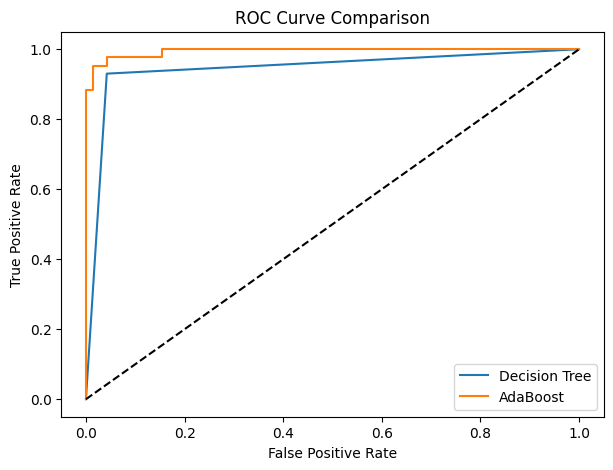

In [10]:
# Calculate ROC curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

# Plot ROC curves
plt.figure(figsize=(7,5))

plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()